In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from allensdk.brain_observatory.behavior.behavior_project_cache.\
    behavior_neuropixels_project_cache \
    import VisualBehaviorNeuropixelsProjectCache

%matplotlib inline

In [2]:
# Update this to a valid directory in your filesystem. This is where the data will be stored.
cache_dir = './data/'
cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=cache_dir) #from_s3_cache(cache_dir=cache_dir)

# get the metadata tables
units_table = cache.get_unit_table()
channels_table = cache.get_channel_table()
probes_table = cache.get_probe_table()
behavior_sessions_table = cache.get_behavior_session_table()
ecephys_sessions_table = cache.get_ecephys_session_table()

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\allensdk\api\cloud_cache\cloud_cache.py:547: OutdatedManifestWarning: You are loading visual-behavior-neuropixels_project_manifest_v0.5.0.json. A more up to date version of the dataset -- visual-behavior-ophys_project_manifest_v1.1.0.json -- exists online. To see the changes between the two versions of the dataset, run
VisualBehaviorNeuropixelsProjectCache.compare_manifests('visual-behavior-neuropixels_project_manifest_v0.5.0.json', 'visual-behavior-ophys_project_manifest_v1.1.0.json')
To load another version of the dataset, run
VisualBehaviorNeuropixelsProjectCache.load_manifest('visual-behavior-ophys_project_manifest_v1.1.0.json')
  warnings.warn(msg, OutdatedManifestWarning)


In [3]:
session_id = 1065437523 #1064644573
session = cache.get_ecephys_session(
            ecephys_session_id=session_id)

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:772: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Load Relevant Data

In [4]:
# Get Neural Data
units = session.get_units()
channels = session.get_channels()
unit_channels = units.merge(channels, left_on='peak_channel_id', right_index=True)

#first let's sort our units by depth
unit_channels = unit_channels.sort_values('probe_vertical_position', ascending=False)

#now we'll filter them
good_unit_filter = ((unit_channels['snr']>1)&
                    (unit_channels['isi_violations']<1)&
                    (unit_channels['firing_rate']>0.1))
good_units = unit_channels.loc[good_unit_filter]


# Unit info
unit_indices = np.array(good_units.index)
spike_times = dict([(i,session.spike_times[i]) for i in unit_indices])
structures = dict(good_units.structure_acronym)

# Stimulus Data
stimulus_presentations = session.stimulus_presentations
# Active stimulus
active_stimulus_presentations = stimulus_presentations[stimulus_presentations["active"]]
# Active Stimulus: Time, Name, Is Change
onset_times = active_stimulus_presentations['start_time'].values
image_names = active_stimulus_presentations['image_name'].values
image_is_changes = active_stimulus_presentations['is_change'].values


# Behavioral Data
eye_tracking = session.eye_tracking
running_speed = session.running_speed
licks = session.licks

Pre Compute Bins

In [73]:
first_onset_time = onset_times[0]
last_onset_time = onset_times[-1]

bin_size = 0.025
buffer = 1.0
bin_start_times = np.arange(first_onset_time-buffer, last_onset_time+buffer, bin_size)
bin_end_times = np.arange(first_onset_time+bin_size-buffer, last_onset_time+bin_size+buffer, bin_size)

num_bins = len(bin_start_times)

Get Binned Spike Counts

In [74]:
num_units = len(spike_times)

Y = np.zeros((num_units, num_bins)) # num of neurons, time steps

# For each unit
for k, unit_idx in enumerate(unit_indices):
    # Select corresponding unit's spike times
    unit_spike_times = spike_times[unit_idx]

    # Find the correct indices of the unit spike times for each bin
    start_indices = np.searchsorted(unit_spike_times, bin_start_times)
    stop_indices = np.searchsorted(unit_spike_times, bin_end_times)

    # Get the counts for each bin
    counts = stop_indices - start_indices
    Y[k] = counts

In [94]:
num_inputs = 8 + 1 + 2 + 3 # images, omit, task, behavior

X = np.zeros((num_inputs, num_bins))

Get Images + Omissions

In [95]:
# Getting Images

unique_images = list(np.unique(image_names))

for onset_time,image_name in zip(onset_times, image_names):
    # get image id
    image_id = unique_images.index(image_name)

    # get image time index
    time_idx = np.searchsorted(bin_start_times, onset_time)-1

    X[image_id, time_idx] = 1.0

Get Task

In [96]:
trials = session.trials
trial_start_times = trials.start_time.values
trial_hits = trials.hit.values
trial_misses = trials.miss.values

hit_start_times = trial_start_times[trial_hits]
miss_start_times = trial_start_times[trial_misses]

hit_start_indices = np.searchsorted(hit_start_times, bin_start_times)
hit_stop_indices = np.searchsorted(hit_start_times, bin_end_times)

miss_start_indices = np.searchsorted(miss_start_times, bin_start_times)
miss_stop_indices = np.searchsorted(miss_start_times, bin_end_times)

hit_counts = hit_stop_indices - hit_start_indices
miss_counts = miss_stop_indices - miss_start_indices

X[9] = 1.0*(hit_counts > 0.0)
X[9+1] = 1.0*(miss_counts > 0.0)

Get Behavior

In [98]:
# Running
run_start_indices = np.searchsorted(running_speed.timestamps, bin_start_times)
run_end_indices = np.searchsorted(running_speed.timestamps, bin_end_times)

for time_idx, (run_start_idx, run_end_idx) in enumerate(zip(run_start_indices, run_end_indices)):
    bin_values = running_speed.speed.values[run_start_idx:run_end_idx]
    bin_values = bin_values[~np.isnan(bin_values)]

    # have to include this in case there's not enough values in time frame
    while len(bin_values) < 1:
        run_start_idx -= 1
        run_end_idx += 1
        bin_values = running_speed.speed.values[run_start_idx:run_end_idx]
        bin_values = bin_values[~np.isnan(bin_values)]

    mean_value = np.nanmean(bin_values)
    X[9+2, time_idx] = mean_value


# Pupil
eye_start_indices = np.searchsorted(eye_tracking.timestamps, bin_start_times)
eye_end_indices = np.searchsorted(eye_tracking.timestamps, bin_end_times)

for time_idx, (eye_start_idx, eye_end_idx) in enumerate(zip(eye_start_indices, eye_end_indices)):
    bin_values = eye_tracking.pupil_area.values[eye_start_idx:eye_end_idx]
    bin_values = bin_values[~np.isnan(bin_values)]

    # have to include this in case there's not enough values in time frame
    while len(bin_values) < 1:
        eye_start_idx -= 1
        eye_end_idx += 1
        bin_values = eye_tracking.pupil_area.values[eye_start_idx:eye_end_idx]
        bin_values = bin_values[~np.isnan(bin_values)]

    mean_value = np.nanmean(bin_values)
    X[9+2+1, time_idx] = mean_value


# Licking
start_indices = np.searchsorted(licks.timestamps, bin_start_times)
stop_indices = np.searchsorted(licks.timestamps, bin_end_times)

# Get the counts for each bin
counts = stop_indices - start_indices
X[9+2+2] = 1.0*(counts > 0.0)

In [99]:
X.shape, Y.shape

((14, 144094), (1803, 144094))

In [100]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression

In [107]:
scores = []
for i in range(10):
    lr = LinearRegression()
    lr.fit(X.T, Y[i:i+1].T)
    score = lr.score(X.T, Y[i:i+1].T)
    scores.append(score)

In [113]:
lr.fit(X.T, Y[:1000].T)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [115]:
pred = lr.predict(X.T)

In [116]:
pred.shape

(144094, 1000)

In [120]:
mses = np.mean((pred - Y[:1000].T)**2, axis=0)

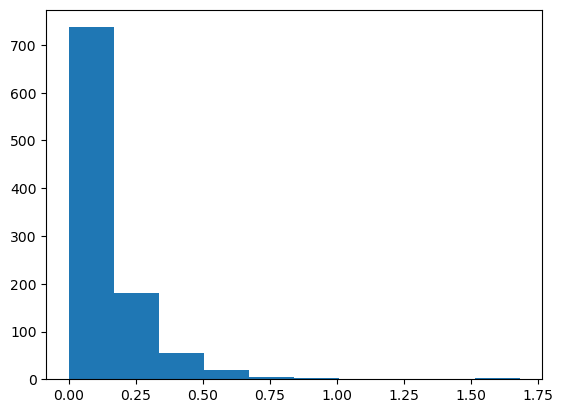

In [ ]:
plt.hist(mses)
plt.show()